In [1]:
# Import libraries 
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt

In [2]:
# Load the train/test sets built in Week 3 
# (time-based split: X months -> train, latest month -> test)
train_df = pd.read_csv("output/train.csv")
test_df = pd.read_csv("output/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (173243, 73)
Test shape: (12434, 73)


,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,DaysOnMarket,LivingArea_was_missing,BathroomsTotalInteger_was_missing,LotSizeSquareFeet_was_missing,YearBuilt_was_missing,...,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba,ClosePrice
0,-0.954370,4.677409,2.835194,-0.486048,0.118594,0.773174,0,0,0,0,...,False,False,False,False,False,False,False,False,False,1120000.0
1,-0.644458,-0.506330,-1.368948,-0.476767,-1.295108,-0.761471,0,0,0,0,...,False,False,False,False,False,False,False,False,False,890000.0
2,0.930287,1.567165,0.312709,-0.688373,0.916067,-0.761471,0,0,0,0,...,False,False,False,False,False,False,False,False,False,1138000.0
3,-1.338748,-1.543078,-1.368948,2.438468,-0.860122,-0.761471,0,0,0,0,...,False,False,False,False,False,False,False,False,False,670000.0
4,0.877723,1.567165,0.312709,-0.387839,1.749788,-0.761471,0,0,0,0,...,False,False,False,False,False,False,False,False,False,681877.0


In [3]:
# Split each set into features (X) and target (y); ClosePrice is the target, already numeric from Week 3
X_train_full = train_df.drop(columns=["ClosePrice"])
y_train = train_df["ClosePrice"]

X_test_full = test_df.drop(columns=["ClosePrice"])
y_test = test_df["ClosePrice"]

print(X_train_full.shape, y_train.shape)
print(X_test_full.shape, y_test.shape)

(173243, 72) (173243,)
(12434, 72) (12434,)


In [4]:
# Use a small set of core numeric property features for the baseline model, same as before
baseline_features = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "DaysOnMarket",
]

X_train = X_train_full[baseline_features].copy()
X_test = X_test_full[baseline_features].copy()

print("Feature matrix shape:", X_train.shape)

Feature matrix shape: (173243, 6)


In [5]:
# Train the baseline Linear Regression model on the time-based training split
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression model training complete.")

Linear Regression model training complete.


In [6]:
# Predict on the held-out test month and evaluate with R², MAE, and RMSE
y_pred = linear_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Linear Regression Results (time-based split)")
print("------------------------------------------------------")
print(f"R² Score:  {r2:.4f}")
print(f"MAE:       ${mae:,.0f}")
print(f"RMSE:      ${rmse:,.0f}")

Baseline Linear Regression Results (time-based split)
------------------------------------------------------
R² Score:  0.5019
MAE:       $420,885
RMSE:      $602,151


In [9]:
# MAPE / MdAPE, so this baseline is comparable to the full-feature models later on
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

mape_val = mape(y_test, y_pred)
mdape_val = mdape(y_test, y_pred)

print(f"MAPE:      {mape_val:.2f}%")
print(f"MdAPE:     {mdape_val:.2f}%")

MAPE:      45.05%
MdAPE:     29.65%


In [10]:
# Store the baseline results for comparison against future models
baseline_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "Split": ["Time-based (Week 3 tuned X)"],
    "Features": [", ".join(baseline_features)],
    "R2": [r2],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape_val],
    "MdAPE": [mdape_val],
})
baseline_results

,Model,Split,Features,R2,MAE,RMSE,MAPE,MdAPE
0,Linear Regression,Time-based (Week 3 tuned X),"LivingArea, BedroomsTotal, BathroomsTotalInteg...",0.501939,420884.929935,602150.734171,45.049471,29.649209


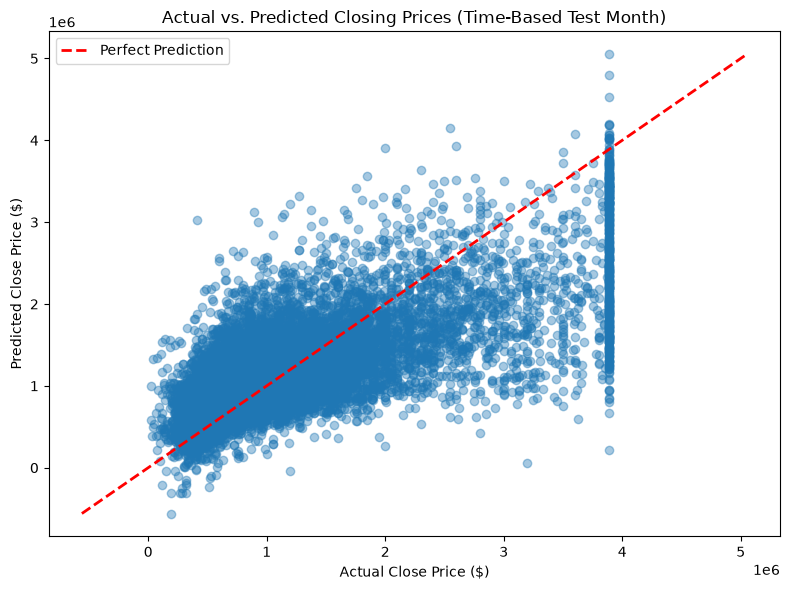

In [8]:
# Visualize predicted vs. actual closing prices against the ideal y = x line
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], "r--", linewidth=2, label="Perfect Prediction")

plt.title("Actual vs. Predicted Closing Prices (Time-Based Test Month)")
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.legend()
plt.tight_layout()
plt.show()